# Real vs. Fake Face Detection
Exploratory Training and Data Cleaning


## Decisions used throughout the notebook

### One label convention

The entire notebook uses:

- **Real = 0**
- **Fake = 1**

This means that a model probability above `0.50` represents a prediction of **Fake**.  
When precision, recall, or F1 score is reported for the positive class, the positive class is always **Fake**.

### One shared train/validation sample

All classification models use the same reproducibly selected image paths, as outlined in the initial variables.

Each model transforms those same images differently, but the underlying training and validation observations stay the same. This makes the final model comparison more meaningful.

The official test folder remains untouched until the model choices are finalized.

### Reproducibility

The notebook uses a fixed seed variable for:

- Python's `random` module;
- NumPy;
- PyTorch;
- image sampling;
- path shuffling;
- DataLoader shuffling;
- model initialization.

Each neural-network experiment recreates its own DataLoader with a new generator seeded at the fixed seed variable. This means rerunning an experiment cell starts from the same intended shuffle order rather than continuing from an older generator state.

A fixed seed does not guarantee bit-for-bit identical results across every hardware and software version, but it removes the main controllable sources of randomness in this notebook.

### Variable and result management

Each experiment uses descriptive variable names such as `pca_train_features`, `fft_logistic_model`, and `raw_rgb_cnn_model`.

Metric functions return values without modifying a global results dictionary. The final comparison table is built explicitly from the result produced by each experiment. This makes missing or failed experiment runs visible instead of silently displaying an older saved metric.


# 1. Overview
## Data Exploration

This notebook explores the 140K Real and Fake Faces dataset used by Synthetic Sight.

The goal is to understand the structure, composition, class distribution, and visual characteristics of the dataset before preprocessing and model development.

This notebook focuses on exploratory analysis only. Data preprocessing and model training are handled in subsequent notebooks.

# 2. Setup

In [ ]:
!git clone -b data-organization https://github.com/Shloka-16/deepfake-detection.git
import sys
sys.path.append('/content/deepfake-detection')

In [ ]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from google.colab import userdata
import subprocess

from src.config import SEED

## 3. Download the dataset from Kaggle

The dataset is the **140k Real and Fake Faces** collection. It contains FFHQ real-face images and StyleGAN-generated fake-face images.

The Kaggle API token should be stored in **Colab Secrets** under the name `KAGGLE_API_TOKEN`. The token is written only to the temporary Colab runtime and should never be committed to GitHub.

The function checks whether the expected dataset folder already exists before downloading it again.

In [2]:
DATASET_ROOT = Path("/content/real_vs_fake/real-vs-fake")


def download_kaggle_dataset(
    dataset_name="xhlulu/140k-real-and-fake-faces",
    download_directory=Path("/content"),
):
    """Download and unzip the Kaggle dataset into the Colab runtime."""
    if DATASET_ROOT.exists():
        print(f"Dataset already found at: {DATASET_ROOT}")
        return

    kaggle_token = userdata.get("KAGGLE_API_TOKEN")
    if not kaggle_token:
        raise ValueError("KAGGLE_API_TOKEN was not found in Colab Secrets.")

    kaggle_directory = Path.home() / ".kaggle"
    kaggle_directory.mkdir(parents=True, exist_ok=True)

    token_path = kaggle_directory / "access_token"
    token_path.write_text(kaggle_token)
    token_path.chmod(0o600)

    print(f"Downloading Kaggle dataset: {dataset_name}")

    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            dataset_name,
            "--unzip",
            "-p",
            str(download_directory),
        ],
        check=True,
    )
    print("Dataset download and extraction complete.")


download_kaggle_dataset()

NameError: name 'userdata' is not defined

## 4. Locate and audit the dataset

The dataset provides separate `train`, `valid`, and `test` folders. Each split contains a `real` folder and a `fake` folder.

This cell creates clearly named path lists for every split and prints their sizes. Later experiments refer to these lists instead of repeatedly searching the filesystem.

Checking the counts first helps catch an incomplete download or an incorrect path before model training begins.

In [ ]:
TRAIN_REAL_DIRECTORY = DATASET_ROOT / "train" / "real"
TRAIN_FAKE_DIRECTORY = DATASET_ROOT / "train" / "fake"

VALID_REAL_DIRECTORY = DATASET_ROOT / "valid" / "real"
VALID_FAKE_DIRECTORY = DATASET_ROOT / "valid" / "fake"

TEST_REAL_DIRECTORY = DATASET_ROOT / "test" / "real"
TEST_FAKE_DIRECTORY = DATASET_ROOT / "test" / "fake"


def list_image_paths(directory):
    """Return sorted image paths from one class directory."""
    return sorted(
        path
        for path in directory.glob("*")
        if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )


train_real_paths = list_image_paths(TRAIN_REAL_DIRECTORY)
train_fake_paths = list_image_paths(TRAIN_FAKE_DIRECTORY)

valid_real_paths = list_image_paths(VALID_REAL_DIRECTORY)
valid_fake_paths = list_image_paths(VALID_FAKE_DIRECTORY)

test_real_paths = list_image_paths(TEST_REAL_DIRECTORY)
test_fake_paths = list_image_paths(TEST_FAKE_DIRECTORY)


dataset_count_table = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Real": len(train_real_paths),
            "Fake": len(train_fake_paths),
        },
        {
            "Split": "Validation",
            "Real": len(valid_real_paths),
            "Fake": len(valid_fake_paths),
        },
        {"Split": "Test", "Real": len(test_real_paths), "Fake": len(test_fake_paths)},
    ]
)

display(dataset_count_table)

if dataset_count_table[["Real", "Fake"]].min().min() == 0:
    raise FileNotFoundError(
        "At least one dataset folder is empty. Recheck DATASET_ROOT and the download."
    )

,Split,Real,Fake
0,Train,50000,50000
1,Validation,10000,10000
2,Test,10000,10000


## 6. Visual check

Before calculating features, confirm that all the files open correctly and that the two classes look like the type of data that is expected.

The sample is selected with seed variable, so rerunning the cell displays the same images. This makes notebook comparisons easier and prevents the written observations from referring to a different random sample after every run.

A visual check cannot prove that the dataset is unbiased or that a model will generalize. It is only an initial quality-control step.

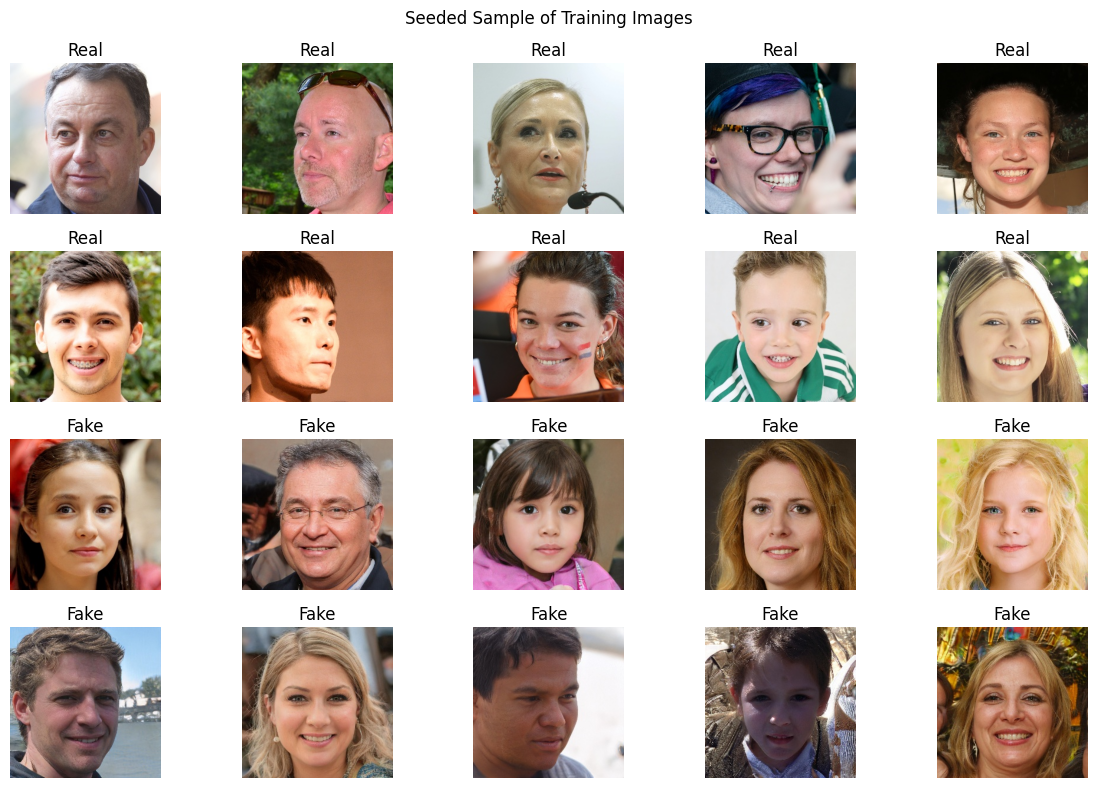

In [ ]:
visual_rng = random.Random(SEED)

visual_real_paths = visual_rng.sample(train_real_paths, 10)
visual_fake_paths = visual_rng.sample(train_fake_paths, 10)

figure, axes = plt.subplots(4, 5, figsize=(12, 8))

# Plot real images in the first two rows
for i, image_path in enumerate(visual_real_paths):
    row_idx = i // 5  # For i=0..4, row_idx=0. For i=5..9, row_idx=1.
    col_idx = i % 5   # For i=0..9, col_idx cycles 0,1,2,3,4.
    with Image.open(image_path) as image:
        axes[row_idx, col_idx].imshow(image.convert("RGB"))
    axes[row_idx, col_idx].set_title("Real")
    axes[row_idx, col_idx].axis("off")

# Plot fake images in the last two rows
for i, image_path in enumerate(visual_fake_paths):
    row_idx = (i // 5) + 2 # For i=0..4, row_idx=2. For i=5..9, row_idx=3.
    col_idx = i % 5      # For i=0..9, col_idx cycles 0,1,2,3,4.
    with Image.open(image_path) as image:
        axes[row_idx, col_idx].imshow(image.convert("RGB"))
    axes[row_idx, col_idx].set_title("Fake")
    axes[row_idx, col_idx].axis("off")

plt.suptitle("Seeded Sample of Training Images")
plt.tight_layout()
plt.show()

### Initial observation

The images are centered face crops, and many fake images are visually convincing.

The next two sections test broad class-level patterns. These are exploratory checks, not full classifiers.



## 7. Average images

An average image is created by resizing many images to the same dimensions and averaging each pixel location across the class.

This can reveal broad alignment differences. For example, one class might be more consistently centered or have more similar backgrounds. It does not show the appearance of a typical individual image; averaging blends faces together.

The same images from each class are selected every time because the function receives the fixed seed variable.

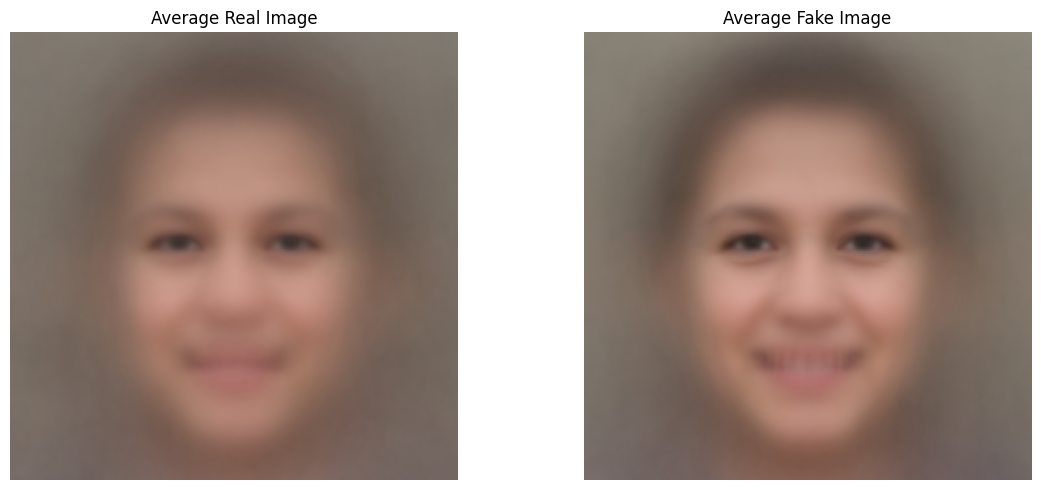

In [ ]:
def compute_average_image(
    image_paths, sample_size=1000, image_size=(256, 256), seed=SEED
):
    """Calculate a reproducible pixel-wise average image."""
    sample_rng = random.Random(seed)
    selected_paths = sample_rng.sample(list(image_paths), sample_size)

    image_arrays = []
    for image_path in selected_paths:
        with Image.open(image_path) as image:
            resized_rgb_image = image.convert("RGB").resize(image_size)
            image_arrays.append(np.asarray(resized_rgb_image, dtype=np.float32))

    return np.mean(image_arrays, axis=0) / 255.0


average_real_image = compute_average_image(
    train_real_paths,
    sample_size=1000,
    seed=SEED,
)
average_fake_image = compute_average_image(
    train_fake_paths,
    sample_size=1000,
    seed=SEED,
)

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(average_real_image)
axes[0].set_title("Average Real Image")
axes[0].axis("off")

axes[1].imshow(average_fake_image)
axes[1].set_title("Average Fake Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### What this tells us:

If one average looks sharper or more symmetrical, that may reflect differences in alignment, image generation, or source preprocessing. It does not necessarily represent a meaningful deepfake artifact.

Because average images discard almost all individual variation, the next check keeps one summary value per image: average brightness.

## 8. Brightness distributions

For each image, this section calculates the mean value of all RGB pixels. The result is one brightness value per image.

The histograms show whether one class is generally lighter or darker. Strong overlap would mean that brightness is not enough to separate the classes by itself.

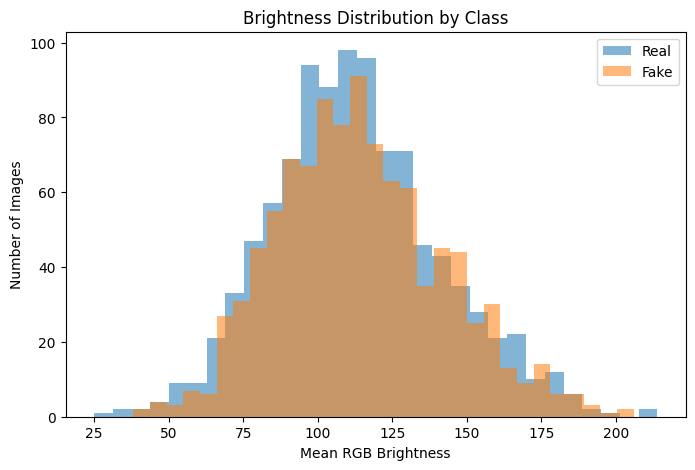

Real mean brightness: 112.81
Fake mean brightness: 114.12


In [ ]:
def compute_brightness_values(image_paths, sample_size=1000, seed=SEED):
    """Calculate reproducible mean RGB brightness values."""
    sample_rng = random.Random(seed)
    selected_paths = sample_rng.sample(list(image_paths), sample_size)

    brightness_values = []
    for image_path in selected_paths:
        with Image.open(image_path) as image:
            rgb_array = np.asarray(image.convert("RGB"), dtype=np.float32)
        brightness_values.append(float(rgb_array.mean()))

    return np.array(brightness_values)


real_brightness_values = compute_brightness_values(
    train_real_paths,
    sample_size=1000,
    seed=SEED,
)
fake_brightness_values = compute_brightness_values(
    train_fake_paths,
    sample_size=1000,
    seed=SEED,
)

plt.figure(figsize=(8, 5))
plt.hist(real_brightness_values, bins=30, alpha=0.55, label="Real")
plt.hist(fake_brightness_values, bins=30, alpha=0.55, label="Fake")
plt.xlabel("Mean RGB Brightness")
plt.ylabel("Number of Images")
plt.title("Brightness Distribution by Class")
plt.legend()
plt.show()

print(f"Real mean brightness: {real_brightness_values.mean():.2f}")
print(f"Fake mean brightness: {fake_brightness_values.mean():.2f}")

### Brightness conclusion

If the distributions overlap substantially, brightness is not a strong standalone feature. A classifier needs information about many pixel locations or patterns rather than one image-wide average.

PCA is the first method used to reduce the full pixel representation into a smaller set of features.

## 9. Conclusions
### Key Findings

- The dataset contains separate training, validation, and test splits.
- Both real and synthetic face images are represented in each split.
- The images are primarily centered human face crops.
- Real and fake images can be visually similar, motivating the use of learned image features.
- Simple image-level characteristics such as brightness provide useful context but are not sufficient on their own to distinguish the two classes.